In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/datset.csv")

print(df)

    No   Outlook Temperature Humidity    Wind Play Tennis
0    1     Sunny         Hot     High    Weak          No
1    2     Sunny         Hot     High  Strong          No
2    3  Overcast         Hot     High    Weak         Yes
3    4      Rain        Mild     High    Weak         Yes
4    5      Rain        Cool   Normal    Weak         Yes
5    6      Rain        Cool   Normal  Strong          No
6    7  Overcast        Cool   Normal  Strong         Yes
7    8     Sunny        Mild     High    Weak          No
8    9     Sunny        Cool   Normal    Weak         Yes
9   10      Rain        Mild   Normal    Weak         Yes
10  11     Sunny        Mild   Normal  Strong         Yes
11  12  Overcast        Mild     High  Strong         Yes
12  13  Overcast         Hot   Normal    Weak         Yes
13  14      Rain        Mild     High  Strong          No
14  15     Sunny        Cool     High    Weak          No
15  16     Sunny        Cool     High  Strong          No
16  17     Sun

This cell loads the `datset.csv` file into a pandas DataFrame named `df` and then prints the entire DataFrame to display its contents. We can see all 50 rows and 6 columns, including the 'No' column (an identifier), categorical features like 'Outlook', 'Temperature', 'Humidity', 'Wind', and the target variable 'Play Tennis'.

In [ ]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

First 5 Rows:
   No   Outlook Temperature Humidity    Wind Play Tennis
0   1     Sunny         Hot     High    Weak          No
1   2     Sunny         Hot     High  Strong          No
2   3  Overcast         Hot     High    Weak         Yes
3   4      Rain        Mild     High    Weak         Yes
4   5      Rain        Cool   Normal    Weak         Yes

Dataset Shape:
(50, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   No           50 non-null     int64 
 1   Outlook      50 non-null     object
 2   Temperature  50 non-null     object
 3   Humidity     50 non-null     object
 4   Wind         50 non-null     object
 5   Play Tennis  50 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.5+ KB
None


This cell provides an initial overview of the loaded dataset. It shows the first 5 rows of the DataFrame, confirms its shape (50 rows, 6 columns), and displays the data types for each column using `df.info()`. All feature columns and the target column are of `object` type, indicating they are categorical strings, while the 'No' column is an integer.

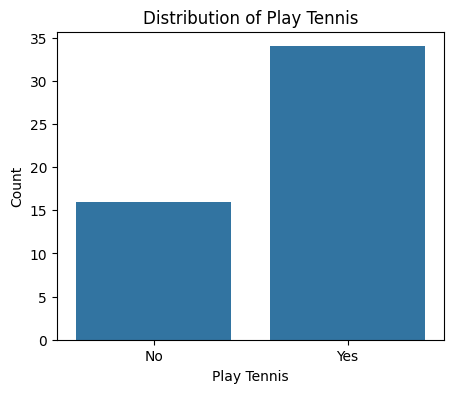

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Play Tennis', data=df)

plt.title("Distribution of Play Tennis")
plt.xlabel("Play Tennis")
plt.ylabel("Count")

plt.show()

In [ ]:
print("Null Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Null Values in Each Column:
No             0
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64

Total Missing Values: 0


This cell checks for any missing (null) values across all columns in the dataset. The output confirms that there are no null values in any of the columns, meaning the dataset is complete and does not require imputation for missing data.

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": missing_percentage
})

print("Missing Value Analysis:")
print(missing_df)

Missing Value Analysis:
             Missing Values  Percentage (%)
No                        0             0.0
Outlook                   0             0.0
Temperature               0             0.0
Humidity                  0             0.0
Wind                      0             0.0
Play Tennis               0             0.0


This cell elaborates on the missing value analysis by calculating and displaying the percentage of missing values for each column. As expected from the previous check, all columns show 0 missing values and 0% missing data, reinforcing that the dataset is clean in terms of completeness.

In [ ]:
print("Number of Duplicate Rows:", df.duplicated().sum())

# Uncomment the following line to remove duplicates if any
# df = df.drop_duplicates()

Number of Duplicate Rows: 0


This cell checks for duplicate rows in the dataset. The output indicates that there are no duplicate rows, meaning each entry in the dataset is unique. This is good for model training as it prevents bias from repeated observations.

In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
No              int64
Outlook        object
Temperature    object
Humidity       object
Wind           object
Play Tennis    object
dtype: object


This cell explicitly prints the data types of all columns in the DataFrame. It reconfirms that 'No' is `int64` and all other columns ('Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis') are `object` type, which is consistent with their categorical nature and the need for encoding.

In [ ]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


No:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]

Outlook:
['Sunny' 'Overcast' 'Rain']

Temperature:
['Hot' 'Mild' 'Cool']

Humidity:
['High' 'Normal']

Wind:
['Weak' 'Strong']

Play Tennis:
['No' 'Yes']


This cell displays all unique values for each column. This is crucial for understanding the distinct categories within each feature and the target variable. For example, 'Outlook' has 'Sunny', 'Overcast', 'Rain'; 'Temperature' has 'Hot', 'Mild', 'Cool'; and 'Play Tennis' has 'No', 'Yes'. This helps confirm the categorical nature of the data before encoding.

In [ ]:
# Features and target
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play Tennis']

# Encode features
feature_encoders = {}

for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    feature_encoders[column] = le

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Encoded Features:")
print(X)

print("\nEncoded Target:")
print(y)

Encoded Features:
    Outlook  Temperature  Humidity  Wind
0         2            1         0     1
1         2            1         0     0
2         0            1         0     1
3         1            2         0     1
4         1            0         1     1
5         1            0         1     0
6         0            0         1     0
7         2            2         0     1
8         2            0         1     1
9         1            2         1     1
10        2            2         1     0
11        0            2         0     0
12        0            1         1     1
13        1            2         0     0
14        2            0         0     1
15        2            0         0     0
16        2            1         1     1
17        2            1         1     0
18        0            0         0     1
19        0            0         0     0
20        0            2         1     1
21        0            2         1     0
22        1            1         0     

/tmp/ipykernel_4920/3388832104.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = le.fit_transform(X[column])
/tmp/ipykernel_4920/3388832104.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = le.fit_transform(X[column])
/tmp/ipykernel_4920/3388832104.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

This cell performs the crucial data preprocessing step of converting categorical features and the target variable into numerical representations using `LabelEncoder`. It separates the features (`X`) from the target (`y`), then iterates through each feature column to encode it. Finally, it encodes the target variable. The output displays the encoded `X` DataFrame and the encoded `y` array, showing the numerical mapping of the original categorical values.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 40
Testing Samples: 10


This cell divides the preprocessed dataset into training and testing subsets using `train_test_split` with an 80:20 ratio. `random_state=42` ensures reproducibility, and `stratify=y` maintains the proportion of target classes in both subsets, which is important for imbalanced datasets. The output shows the number of samples allocated to the training and testing sets.

In [ ]:
nb = CategoricalNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

Accuracy: 0.9

Confusion Matrix
[[2 1]
 [0 7]]

Classification Report
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



This cell evaluates the performance of the trained Categorical Naive Bayes model on the test set. It calculates and prints the overall accuracy, the confusion matrix (showing true positives, true negatives, false positives, false negatives), and a classification report (including precision, recall, and f1-score for each class and their averages). This gives a comprehensive view of how well the Naive Bayes model performed.

In [ ]:
sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

for column in sample.columns:
    sample[column] = feature_encoders[column].transform(sample[column])

prediction = nb.predict(sample)
probability = nb.predict_proba(sample)

print("Predicted Class:",
      target_encoder.inverse_transform(prediction)[0])

print("\nClass Probabilities:")

for cls, prob in zip(target_encoder.classes_, probability[0]):
    print(f"{cls}: {prob:.4f}")

Predicted Class: No

Class Probabilities:
No: 0.7894
Yes: 0.2106


This cell performs a single-sample inference using the trained Categorical Naive Bayes model. It defines a new sample with specific weather conditions, encodes these conditions using the same encoders fitted during training, and then predicts the class label ('Play Tennis' or 'No Play Tennis') and the probability for each class. The output shows the predicted class ('No' in this case) and the corresponding probabilities, indicating the model's confidence in its prediction.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

dt_sample = dt.predict(sample)

dt_prob = dt.predict_proba(sample)

print("Decision Tree Accuracy:", dt_acc)
print("Prediction:", target_encoder.inverse_transform(dt_sample)[0])
print("Probabilities:", dt_prob)

Decision Tree Accuracy: 1.0
Prediction: No
Probabilities: [[1. 0.]]


This cell trains a Decision Tree Classifier on the same training data and evaluates its performance. It calculates the accuracy on the test set and then performs a single-sample prediction for the same conditions used earlier. The output displays the Decision Tree's accuracy, its prediction for the sample, and the class probabilities, allowing for a direct comparison with the Naive Bayes model.

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

lr_sample = lr.predict(sample)

lr_prob = lr.predict_proba(sample)

print("Logistic Regression Accuracy:", lr_acc)
print("Prediction:", target_encoder.inverse_transform(lr_sample)[0])
print("Probabilities:", lr_prob)

Logistic Regression Accuracy: 0.9
Prediction: No
Probabilities: [[0.86132225 0.13867775]]


This cell trains a Logistic Regression model, evaluates its test set accuracy, and performs a single-sample inference. Similar to the previous models, it outputs the Logistic Regression model's accuracy, the predicted label for the specific sample, and the associated class probabilities. This adds another model to our comparison.

In [ ]:
svm = SVC(probability=True, random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

svm_sample = svm.predict(sample)

svm_prob = svm.predict_proba(sample)

print("SVM Accuracy:", svm_acc)
print("Prediction:", target_encoder.inverse_transform(svm_sample)[0])
print("Probabilities:", svm_prob)

SVM Accuracy: 1.0
Prediction: No
Probabilities: [[0.95689943 0.04310057]]


This cell trains a Support Vector Machine (SVM) classifier with probability enabled, evaluates its accuracy on the test set, and performs a single-sample prediction. The output includes the SVM model's accuracy, the predicted class for the sample, and the class probabilities. This completes the training and individual evaluation of all four requested models.

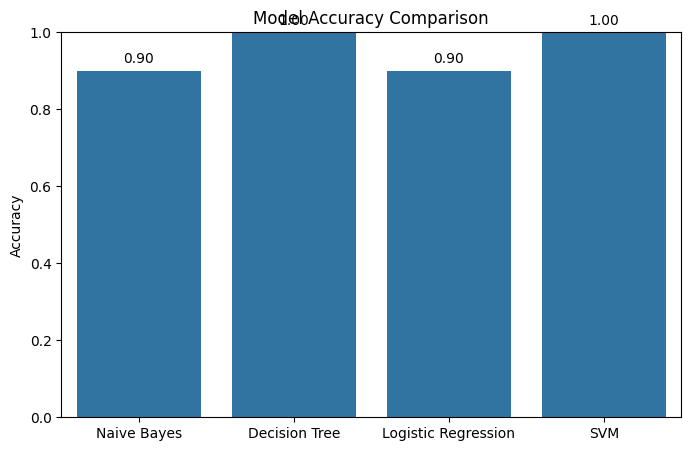

In [ ]:
models = [
    "Naive Bayes",
    "Decision Tree",
    "Logistic Regression",
    "SVM"
]

accuracies = [
    accuracy,
    dt_acc,
    lr_acc,
    svm_acc
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.ylim(0,1)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i,v in enumerate(accuracies):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
print("="*80)
print("{:<25} {:<12} {:<15} {}".format(
    "Model",
    "Accuracy",
    "Prediction",
    "Class Probabilities"
))
print("="*80)

print("{:<25} {:<12.2f} {:<15} {}".format(
    "Categorical Naive Bayes",
    accuracy,
    target_encoder.inverse_transform(prediction)[0],
    probability[0]
))

print("{:<25} {:<12.2f} {:<15} {}".format(
    "Decision Tree",
    dt_acc,
    target_encoder.inverse_transform(dt_sample)[0],
    dt_prob[0]
))

print("{:<25} {:<12.2f} {:<15} {}".format(
    "Logistic Regression",
    lr_acc,
    target_encoder.inverse_transform(lr_sample)[0],
    lr_prob[0]
))

print("{:<25} {:<12.2f} {:<15} {}".format(
    "SVM",
    svm_acc,
    target_encoder.inverse_transform(svm_sample)[0],
    svm_prob[0]
))

Model                     Accuracy     Prediction      Class Probabilities
Categorical Naive Bayes   0.90         No              [0.78944328 0.21055672]
Decision Tree             1.00         No              [1. 0.]
Logistic Regression       0.90         No              [0.86132225 0.13867775]
SVM                       1.00         No              [0.95689943 0.04310057]


This cell provides a clear, formatted comparison table summarizing the performance of all four classification models: Categorical Naive Bayes, Decision Tree, Logistic Regression, and SVM. For each model, it displays the test accuracy, the predicted outcome for the single-sample query, and the corresponding class probabilities. This table allows for an easy side-by-side assessment of how each model performs on both the overall test data and a specific prediction scenario.

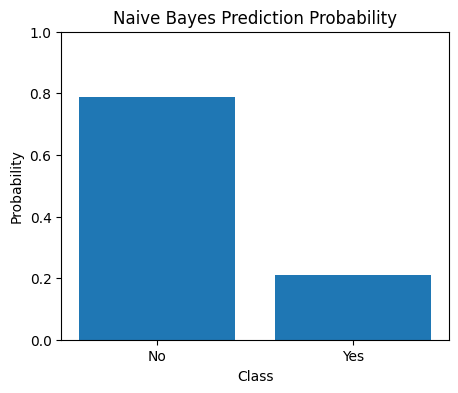

In [ ]:
classes = target_encoder.classes_
prob = probability[0]

plt.figure(figsize=(5,4))

plt.bar(classes, prob)

plt.title("Naive Bayes Prediction Probability")
plt.xlabel("Class")
plt.ylabel("Probability")

plt.ylim(0,1)

plt.show()